这是一个python写成的LBM模拟程序，对象是Poiseuille流动。
模拟区域尺度为1X1(由于长度方向上尺寸对速度分布不会造成影响，所以这里任意取值)，格子点数分别为20X20，格子雷诺数取100，粘度取0.5/3，密度取1.0，压力梯度为1e-4.首先定义一些物理量值

In [ ]:
NX = 20#格子 x 轴 数目 （格点数）
NY = 20#格子 y 轴 数目（格点数）
Q = 9  # D2Q9 有九个方向
Rho0 = 1.0 # 密度
U0 = [0.,0.] # 速度向量 （vx,vy）
Vis = 0.6/3 #运动粘度 
G = 1e-4 # 压力梯度
tau = 3 * Vis + 0.5 # 这里根据运动粘度算出 松弛时间

首先进行一些常用变量的定义，模拟采用经典的D2Q9模型，需要定义9个方向和对应的权重函数

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

e = np.array([[0,0],[1,0],[0,1],[-1,0],[0,-1],[1,1],[-1,1],[-1,-1],[1,-1]])
#定义一个相反的方向量作为反弹边界的方向判定
re = np.array([0,3,4,1,2,7,8,5,6])#相反方向索引
ww = np.array([4.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/36, 1.0/36, 1.0/36, 1.0/36,])# 各个方向的权重（）

定义宏观密度，速度和密度分布数组

In [ ]:
Rho = np.ones((NX,NY), dtype = np.float64)# 每个格点的总密度
U = np.ones((NX, NY, 2), dtype = np.float64) # 速度矢量
UU = np.ones((NX, NY), dtype = np.float64) #速度标量值
#定义一个前一步的速度量来计算相邻两步之间的误差
U_pre = np.ones((NX, NY, 2), dtype = np.float64)
#密度分布函数
f = np.zeros((NX, NY, Q), dtype = np.float64)
#碰撞后迁移前的密度分布函数作为中间存储量
f_col = np.zeros((NX, NY, Q), dtype = np.float64)

定义平衡态分布函数

In [ ]:
def feq(m, RHO, U, V):#计算平衡态分布函数，参数表为 方向索引，密度，宏观速度（x轴），宏观速度（y轴）
    eu = e[m][0] * U + e[m][1] * V
    uv = U * U + V * V
    return ww[m] * RHO * (1.0 + 3.0 * eu + 4.5 * eu * eu - 1.5 * uv)#公式可见视频

定义一个对宏观量和密度分布函数初始化的函数

In [ ]:
def initial():
    for i in range(NX):
        for j in range(NY):
            Rho[i][j] = Rho0
            U[i][j] = U0
            #以平衡态分布函数作为初始的密度分布函数
            for m in range(Q):
                f[i][j][m] = feq(m, Rho[i][j], U[i][j][0], U[i][j][1])#按平衡态分布

定义在一个循环步中的碰撞和演化函数

In [ ]:
def evolution():
    #求碰撞之后的密度分布函数
    for i in range(NX):
        for j in range(NY):
            for m in range(Q):
                f_col[i][j][m] = f[i][j][m] + (feq(m, Rho[i][j], U[i][j][0], U[i][j][1]) - f[i][j][m]) / tau + 3.0 * ww[m] * G * e[m][0];#计算碰撞
    #密度函数量的迁移加边界条件
    for i in range(NX):
        for j in range(NY):
            for m in range(Q):
                #i方向用余数的方法来获得周期性
                ip = (i - e[m][0] + NX) % NX
                jp = j - e[m][1]#计算j方向预期坐标
                if(jp < 0 or jp >= NY):
                    f[i][j][m] = f_col[i][j][re[m]]#如果碰到墙壁，碰撞后会反方向速度回到同一点
                else:
                    f[i][j][m] = f_col[ip][jp][m]#不碰撞就迁移
    #用迁移后的密度分布函数求宏观量
    for i in range(NX):
        for j in range(NY):
            Rho[i][j] = 0.#准备叠加
            U_pre[i][j] = U[i][j]#保存当前时刻U用来计算delta判断是否收敛
            U[i][j] = [0.,0.]#准备叠加
            for m in range(Q):
                Rho[i][j] += f[i][j][m]
                U[i][j][0] += f[i][j][m] * e[m][0]
                U[i][j][1] += f[i][j][m] * e[m][1]
            #if(Rho[i][j] > 0):
            U[i][j][0] /= Rho[i][j]#取加权
            U[i][j][1] /= Rho[i][j]#取加权
            UU[i][j] = math.sqrt(U[i][j][0] * U[i][j][0] + U[i][j][1] * U[i][j][1])#算标量
            #else:
            #    U[i][j] = [0.,0.]

定义一个误差函数

In [ ]:
def error():
    error1 = 0.
    error2 = 0.
    for i in range(NX):
        for j in range(NY):
            error1 = (U[i][j][0] - U_pre[i][j][0]) * (U[i][j][0] - U_pre[i][j][0]) + (U[i][j][1] - U_pre[i][j][1]) * (U[i][j][1] - U_pre[i][j][1])
            error2 = (U[i][j][0] - U_pre[i][j][0]) * (U[i][j][0] - U_pre[i][j][0])
    return error1 / (error2 + 1e-8)

主运行函数，先初始化，然后在一定的时间步长内进行evolution函数的迭代，迭代中检查error函数，如果返回值小于1e-8，认为计算结果达到稳定停止迭代。

In [78]:
initial()
Nmax = int(1e5)
for n in range(Nmax):
    evolution()
    if(n % 100 == 1):
        Err = error()
        print("n = " + str(n) + ", error = " + str(Err) + ";\n")
        if(Err < 1e-7):
            break

n = 1, error = 0.20972423802609053;

n = 101, error = 0.0037879199995777416;

n = 201, error = 0.0013660481131928081;

n = 301, error = 0.0005096585006517782;

n = 401, error = 0.00019018283102480925;

n = 501, error = 7.095493364270754e-05;

n = 601, error = 2.6470463604589924e-05;

n = 701, error = 9.874801781666227e-06;

n = 801, error = 3.683754735668466e-06;

n = 901, error = 1.3742044221052545e-06;

n = 1001, error = 5.126386515593347e-07;

n = 1101, error = 1.9123664634227388e-07;

n = 1201, error = 7.133962183019071e-08;



计算结果画图

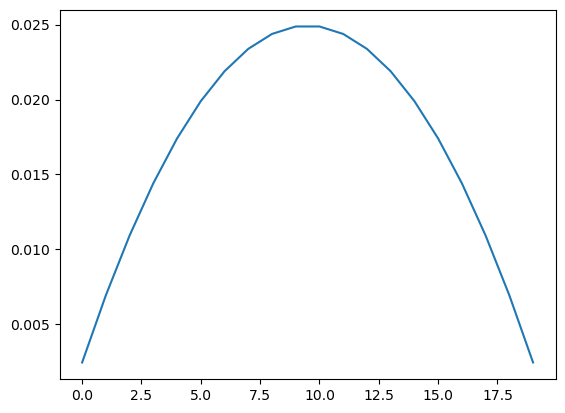

In [80]:
Uplot = U[10]
plt.plot(Uplot[:,0])

C:\Users\admin\AppData\Local\Temp\ipykernel_60888\273023313.py:5: UserWarning: The following kwargs were not used by contour: 'color'
  ax.contourf(yy, xx, UU, color = "k")


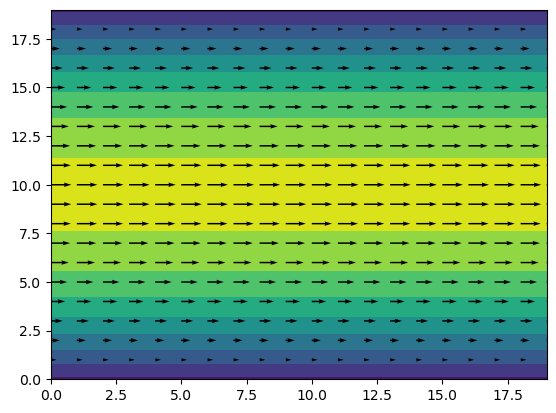

In [84]:
x = np.arange(0, NX, 1)
y = np.arange(0, NY, 1)
xx, yy = np.meshgrid(x, y)
fig, ax = plt.subplots()
ax.contourf(yy, xx, UU, color = "k")
ax.quiver(yy, xx, U[:,:,0], U[:,:,1])